# Klasifikasi Teks dengan TensorFlow/Keras

Notebook ini adalah versi berbahasa Indonesia yang disederhanakan dan diperluas dari tutorial **Basic text classification** TensorFlow. Tutorial aslinya dapat diakses [di sini](https://www.tensorflow.org/tutorials/keras/text_classification).

Kita akan membuat model untuk membaca review film dan memprediksi apakah review tersebut bernada:

- **negatif**
- **positif**

Jenis masalah ini disebut **binary text classification**, karena kelas target hanya ada dua.

---

## Gambaran Besar Proses

Secara konseptual, prosesnya seperti ini:

```text
Review teks mentah
        ↓
Pembersihan teks
        ↓
Tokenisasi dan pengubahan kata menjadi angka
        ↓
Embedding
        ↓
Model neural network
        ↓
Probabilitas review positif
        ↓
Prediksi: negatif / positif
```

Komputer tidak memahami kata secara langsung. Karena itu, teks harus diubah menjadi representasi numerik terlebih dahulu.

## 1. Persiapan Library

Kita akan menggunakan:

- `tensorflow` untuk membangun dan melatih model.
- `keras.layers` untuk membuat layer neural network.
- `matplotlib` untuk membuat grafik.
- `os`, `shutil`, `re`, dan `string` untuk mengelola file dan membersihkan teks.

> Catatan: Jika TensorFlow belum terpasang, jalankan perintah berikut di terminal atau command prompt:
>
> ```bash
> pip install tensorflow matplotlib
> ```

In [4]:
import os
import re
import shutil
import string

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import losses

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Mengunduh Dataset IMDB

Kita menggunakan **Large Movie Review Dataset** dari Stanford.

Dataset ini berisi review film dari IMDB yang sudah diberi label:

- `pos`: review positif
- `neg`: review negatif

Secara umum, dataset ini berisi 50.000 review:
- 25.000 review untuk training
- 25.000 review untuk testing

TensorFlow akan mengunduh file dataset secara otomatis saat sel berikut dijalankan.

In [5]:
url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

dataset_path = tf.keras.utils.get_file(
    "aclImdb_v1.tar.gz",
    url,
    untar=True,
    cache_dir="/content/",
    cache_subdir=""
)

print("Dataset berhasil diunduh atau sudah tersedia di:")
print(dataset_path)

84125825/84125825 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Dataset berhasil diunduh atau sudah tersedia di:
/content/aclImdb_v1_extracted


## 3. Mengecek Struktur Folder Dataset

Untuk menggunakan `text_dataset_from_directory`, struktur folder harus berbentuk seperti ini:

```text
folder_utama/
    kelas_1/
        file_teks_1.txt
        file_teks_2.txt
    kelas_2/
        file_teks_3.txt
        file_teks_4.txt
```

Pada dataset IMDB, folder yang kita butuhkan adalah:

```text
aclImdb/train/pos
aclImdb/train/neg
aclImdb/test/pos
aclImdb/test/neg
```

Namun, di dalam `aclImdb/train` terdapat folder tambahan bernama `unsup` yang tidak memiliki label untuk klasifikasi biner. Karena itu, folder tersebut perlu dihapus agar proses pembacaan dataset menjadi bersih.

In [6]:
base_dir = os.path.dirname(dataset_path)

candidate_dirs = [
    os.path.join(base_dir, "aclImdb"),
    os.path.join(base_dir, "aclImdb_v1_extracted", "aclImdb")
]

dataset_dir = None

for candidate in candidate_dirs:
    if os.path.exists(candidate):
        dataset_dir = candidate
        break

if dataset_dir is None:
    raise FileNotFoundError("Folder aclImdb tidak ditemukan. Cek kembali proses download dan ekstraksi dataset.")

print("Folder dataset:", dataset_dir)
print("Isi folder dataset:", os.listdir(dataset_dir))

Folder dataset: /content/aclImdb_v1_extracted/aclImdb
Isi folder dataset: ['README', 'imdbEr.txt', 'imdb.vocab', 'test', 'train']


In [8]:
train_dir = os.path.join(dataset_dir, "train")
test_dir = os.path.join(dataset_dir, "test")

print("Isi folder train sebelum pembersihan:")
print(os.listdir(train_dir))

unsup_dir = os.path.join(train_dir, "unsup")

# Hapus folder unsup jika masih ada.
# Kode ini aman dijalankan berulang kali.
if os.path.isdir(unsup_dir):
    shutil.rmtree(unsup_dir)
    print("Folder 'unsup' berhasil dihapus.")
else:
    print("Folder 'unsup' sudah tidak ada.")

print("\nIsi folder train setelah pembersihan:")
print(os.listdir(train_dir))

Isi folder train sebelum pembersihan:
['urls_unsup.txt', 'labeledBow.feat', 'neg', 'pos', 'unsupBow.feat', 'urls_pos.txt', 'urls_neg.txt']
Folder 'unsup' sudah tidak ada.

Isi folder train setelah pembersihan:
['urls_unsup.txt', 'labeledBow.feat', 'neg', 'pos', 'unsupBow.feat', 'urls_pos.txt', 'urls_neg.txt']


## 4. Melihat Contoh Isi File Review

Setiap review disimpan sebagai satu file `.txt`.

Mari kita buka salah satu review positif agar mahasiswa memahami bentuk data mentahnya.

In [9]:
sample_file = os.path.join(train_dir, "pos", "1181_9.txt")

with open(sample_file, encoding="utf-8") as f:
    sample_text = f.read()

print(sample_text[:1000])

Rachel Griffiths writes and directs this award winning short film. A heartwarming story about coping with grief and cherishing the memory of those we've loved and lost. Although, only 15 minutes long, Griffiths manages to capture so much emotion and truth onto film in the short space of time. Bud Tingwell gives a touching performance as Will, a widower struggling to cope with his wife's death. Will is confronted by the harsh reality of loneliness and helplessness as he proceeds to take care of Ruth's pet cow, Tulip. The film displays the grief and responsibility one feels for those they have loved and lost. Good cinematography, great direction, and superbly acted. It will bring tears to all those who have lost a loved one, and survived.


## 5. Membuat Dataset Training, Validation, dan Testing

Dalam machine learning, dataset biasanya dibagi menjadi tiga bagian:

| Bagian Data | Fungsi |
|---|---|
| Training data | Dipakai model untuk belajar |
| Validation data | Dipakai untuk memantau performa selama training |
| Test data | Dipakai untuk evaluasi akhir setelah training selesai |

Dataset IMDB sudah memiliki folder `train` dan `test`, tetapi belum memiliki folder validation. Karena itu, kita akan mengambil 20% dari data training sebagai validation set.

In [10]:
batch_size = 32
seed = 42

raw_train_ds = tf.keras.utils.text_dataset_from_directory(
    directory=train_dir,
    batch_size=batch_size,
    validation_split=0.2,
    subset="training",
    seed=seed
)

raw_val_ds = tf.keras.utils.text_dataset_from_directory(
    directory=train_dir,
    batch_size=batch_size,
    validation_split=0.2,
    subset="validation",
    seed=seed
)

raw_test_ds = tf.keras.utils.text_dataset_from_directory(
    directory=test_dir,
    batch_size=batch_size
)

print("\nNama kelas:", raw_train_ds.class_names)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.
Found 25000 files belonging to 2 classes.

Nama kelas: ['neg', 'pos']


## 6. Memahami Label Dataset

Biasanya `text_dataset_from_directory` memberi label berdasarkan urutan nama folder secara alfabetis.

Pada dataset ini biasanya:

```text
0 = neg
1 = pos
```

Mari kita tampilkan beberapa contoh review dan labelnya.

In [11]:
for text_batch, label_batch in raw_train_ds.take(1):
    for i in range(3):
        print("Review:")
        print(text_batch.numpy()[i][:500])
        print("Label angka:", label_batch.numpy()[i])
        print("Label kelas:", raw_train_ds.class_names[label_batch.numpy()[i]])
        print("-" * 80)

Review:
b'"Pandemonium" is a horror movie spoof that comes off more stupid than funny. Believe me when I tell you, I love comedies. Especially comedy spoofs. "Airplane", "The Naked Gun" trilogy, "Blazing Saddles", "High Anxiety", and "Spaceballs" are some of my favorite comedies that spoof a particular genre. "Pandemonium" is not up there with those films. Most of the scenes in this movie had me sitting there in stunned silence because the movie wasn\'t all that funny. There are a few laughs in the film, b'
Label angka: 0
Label kelas: neg
--------------------------------------------------------------------------------
Review:
b"David Mamet is a very interesting and a very un-equal director. His first movie 'House of Games' was the one I liked best, and it set a series of films with characters whose perspective of life changes as they get into complicated situations, and so does the perspective of the viewer.<br /><br />So is 'Homicide' which from the title tries to set the mind of the 

## 7. Pembersihan Teks

Teks mentah biasanya memiliki beberapa hal yang kurang ideal, misalnya:

- huruf besar dan kecil yang tidak konsisten,
- tag HTML seperti `<br />`,
- tanda baca yang mungkin tidak kita perlukan untuk model sederhana.

Kita akan membuat fungsi `custom_standardization` untuk:

1. mengubah teks menjadi huruf kecil,
2. mengganti `<br />` dengan spasi,
3. menghapus tanda baca.

> Penting: Ini bukan satu-satunya cara preprocessing teks. Untuk kasus nyata, preprocessing harus disesuaikan dengan bahasa dan domain data.

In [12]:
@tf.keras.utils.register_keras_serializable(package="Custom")
def custom_standardization(input_text):
    # 1. Ubah semua huruf menjadi huruf kecil
    lowercase = tf.strings.lower(input_text)

    # 2. Ganti tag HTML <br /> dengan spasi
    no_html = tf.strings.regex_replace(lowercase, "<br />", " ")

    # 3. Hapus tanda baca
    return tf.strings.regex_replace(
        no_html,
        "[%s]" % re.escape(string.punctuation),
        ""
    )

In [13]:
contoh_teks = tf.constant(["This movie was GREAT!!!<br />I really loved it."])

print("Sebelum pembersihan:")
print(contoh_teks.numpy()[0].decode("utf-8"))

print("\nSetelah pembersihan:")
print(custom_standardization(contoh_teks).numpy()[0].decode("utf-8"))

Sebelum pembersihan:
This movie was GREAT!!!<br />I really loved it.

Setelah pembersihan:
this movie was great i really loved it


## 8. TextVectorization: Mengubah Teks Menjadi Angka

Model neural network tidak bisa langsung menerima kalimat seperti:

```text
this movie was great
```

Kita harus mengubahnya menjadi angka, misalnya:

```text
[12, 45, 8, 91]
```

Layer `TextVectorization` melakukan beberapa proses penting:

1. **Standardization**: membersihkan teks.
2. **Tokenization**: memecah teks menjadi token/kata.
3. **Indexing**: memberi nomor unik untuk setiap kata.
4. **Padding/Truncating**: menyamakan panjang input.

Parameter penting:

- `max_tokens`: jumlah maksimum kata yang disimpan dalam kosakata.
- `output_mode='int'`: hasilnya berupa urutan angka.
- `output_sequence_length`: panjang setiap review setelah dipotong atau diisi padding.

Contoh:
- Review pendek akan ditambah padding.
- Review terlalu panjang akan dipotong.

In [14]:
max_features = 10000      # Maksimum jumlah kata dalam vocabulary
sequence_length = 250     # Panjang maksimum setiap review setelah vectorization

vectorize_layer = layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=max_features,
    output_mode="int",
    output_sequence_length=sequence_length
)

# Ambil hanya teks dari dataset training, tanpa label.
train_text = raw_train_ds.map(lambda text, label: text)

# adapt() membuat vocabulary berdasarkan data training.
# Jangan gunakan validation/test data untuk adapt, karena itu menyebabkan data leakage.
vectorize_layer.adapt(train_text)

print("Jumlah kata dalam vocabulary:", len(vectorize_layer.get_vocabulary()))
print("10 kata pertama dalam vocabulary:")
print(vectorize_layer.get_vocabulary()[:10])

Jumlah kata dalam vocabulary: 10000
10 kata pertama dalam vocabulary:
['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('a'), np.str_('of'), np.str_('to'), np.str_('is'), np.str_('in'), np.str_('it')]


## 9. Melihat Hasil Vectorization

Sekarang kita lihat bagaimana review mentah berubah menjadi deretan angka.

Perhatikan bahwa setiap kata akan diganti dengan indeks dari vocabulary.

In [16]:
for text_batch, label_batch in raw_train_ds.take(1):
    first_review = text_batch[0]
    first_label = label_batch[0]

    print("Review asli:")
    print(first_review.numpy()[:500])

    print("\nLabel:", raw_train_ds.class_names[first_label.numpy()])

    vectorized_review = vectorize_layer(tf.expand_dims(first_review, -1))

    print("\n20 token pertama setelah vectorization:")
    print(vectorized_review.numpy()[0][:20])
    break

Review asli:
b'Great movie - especially the music - Etta James - "At Last". This speaks volumes when you have finally found that special someone.'

Label: neg

20 token pertama setelah vectorization:
[  86   17  260    2  222    1  571   31  229   11 2418    1   51   22
   25  404  251   12  306  282]


In [17]:
vocab = vectorize_layer.get_vocabulary()

print("Contoh mapping indeks ke kata:")
for index in [1, 2, 3, 10, 100, 1000]:
    if index < len(vocab):
        print(f"{index} -> {vocab[index]}")

Contoh mapping indeks ke kata:
1 -> [UNK]
2 -> the
3 -> and
10 -> i
100 -> characters
1000 -> political


## 10. Menyiapkan Dataset yang Sudah Berupa Angka

Sekarang kita ubah semua dataset:

- training
- validation
- testing

dari bentuk teks mentah menjadi angka.

Setelah proses ini, dataset siap masuk ke model neural network.

In [18]:
def vectorize_text(text, label):
    text = tf.expand_dims(text, -1)
    return vectorize_layer(text), label

train_ds = raw_train_ds.map(vectorize_text)
val_ds = raw_val_ds.map(vectorize_text)
test_ds = raw_test_ds.map(vectorize_text)

for x_batch, y_batch in train_ds.take(1):
    print("Shape input batch:", x_batch.shape)
    print("Shape label batch:", y_batch.shape)
    print("Contoh input pertama, 20 angka pertama:")
    print(x_batch.numpy()[0][:20])

Shape input batch: (32, 250)
Shape label batch: (32,)
Contoh input pertama, 20 angka pertama:
[   1    7    4 1233 1021   27  261  101    4    1 1525 6992  248   32
 1488    1 1659    4   86 1011]


## 11. Optimasi Pipeline Data

Dua fungsi berikut sering dipakai agar training lebih efisien:

- `cache()`: menyimpan data yang sudah diproses agar tidak dihitung ulang terus-menerus.
- `prefetch()`: menyiapkan batch berikutnya saat model sedang training batch saat ini.

Ini berguna agar model tidak terlalu sering menunggu proses input data.

In [19]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

## 12. Membuat Model Neural Network Sederhana

Model yang digunakan terdiri dari beberapa layer:

```text
Embedding
    ↓
Dropout
    ↓
GlobalAveragePooling1D
    ↓
Dropout
    ↓
Dense sigmoid
```

Penjelasan singkat:

| Layer | Fungsi |
|---|---|
| `Embedding` | Mengubah indeks kata menjadi vektor dense |
| `Dropout` | Mengurangi risiko overfitting |
| `GlobalAveragePooling1D` | Merangkum semua vektor kata menjadi satu vektor review |
| `Dense(1, sigmoid)` | Menghasilkan probabilitas review positif |

Output model adalah angka antara 0 dan 1.

Interpretasi sederhana:

```text
mendekati 0 → negatif
mendekati 1 → positif
```

In [20]:
embedding_dim = 16

model = tf.keras.Sequential([
    layers.Embedding(input_dim=max_features, output_dim=embedding_dim),
    layers.Dropout(0.2),
    layers.GlobalAveragePooling1D(),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 13. Compile Model

Sebelum training, model perlu dikonfigurasi dengan:

- **loss function**: fungsi untuk mengukur seberapa salah prediksi model.
- **optimizer**: algoritma untuk memperbaiki bobot model.
- **metric**: ukuran performa yang mudah dibaca manusia.

Karena ini adalah klasifikasi biner, kita gunakan:

```python
BinaryCrossentropy
```

dan metrik:

```python
BinaryAccuracy
```

In [21]:
model.compile(
    loss=losses.BinaryCrossentropy(),
    optimizer="adam",
    metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy", threshold=0.5)]
)

## 14. Training Model

Pada tahap ini, model belajar dari review film.

Sebagai awalan, kita gunakan jumlah epoch yang tidak terlalu besar agar proses training tidak terlalu lama.

> Jika menggunakan CPU, proses ini mungkin memerlukan beberapa menit.

In [22]:
epochs = 5

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6489 - loss: 0.6603 - val_accuracy: 0.7344 - val_loss: 0.6099
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7833 - loss: 0.5468 - val_accuracy: 0.8046 - val_loss: 0.4957
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8313 - loss: 0.4474 - val_accuracy: 0.8374 - val_loss: 0.4214
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8550 - loss: 0.3848 - val_accuracy: 0.8542 - val_loss: 0.3769
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8690 - loss: 0.3442 - val_accuracy: 0.8632 - val_loss: 0.3488


## 15. Evaluasi Model pada Test Set

Setelah training selesai, kita evaluasi model menggunakan test set.

Test set adalah data yang tidak dipakai saat training maupun validation, sehingga lebih adil untuk mengukur kemampuan generalisasi model.

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8475 - loss: 0.3702
Test loss: 0.37018266320228577
Test accuracy: 0.8475199937820435


## 16. Visualisasi Loss dan Akurasi

Grafik membantu kita memahami proses training.

Hal yang perlu diperhatikan:

- Jika training accuracy naik tetapi validation accuracy berhenti naik, model mungkin mulai overfitting.
- Jika training loss turun tetapi validation loss naik, itu juga tanda overfitting.

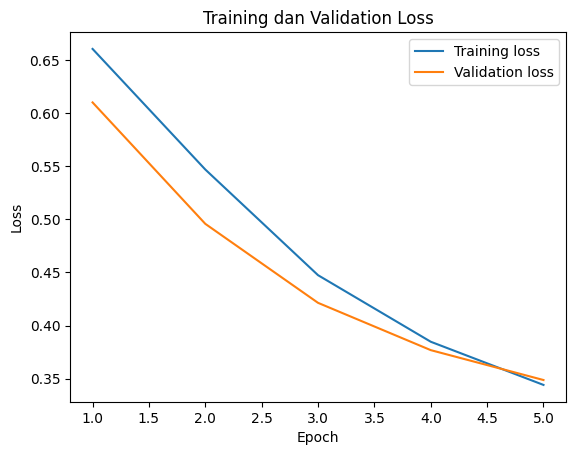

In [23]:
history_dict = history.history

train_loss = history_dict["loss"]
val_loss = history_dict["val_loss"]
train_acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]

epochs_range = range(1, len(train_loss) + 1)

plt.figure()
plt.plot(epochs_range, train_loss, label="Training loss")
plt.plot(epochs_range, val_loss, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training dan Validation Loss")
plt.legend()
plt.show()

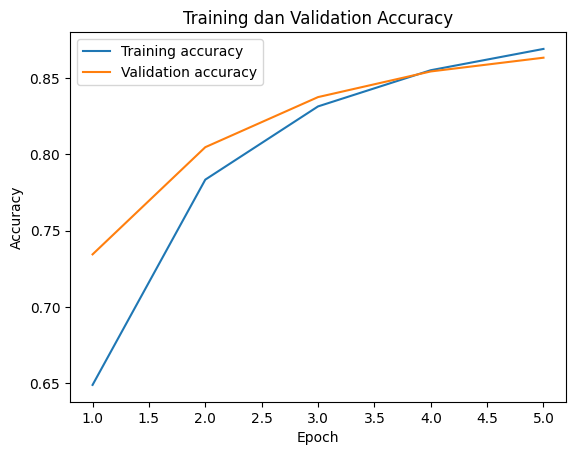

In [24]:
plt.figure()
plt.plot(epochs_range, train_acc, label="Training accuracy")
plt.plot(epochs_range, val_acc, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training dan Validation Accuracy")
plt.legend()
plt.show()

## 17. Confusion Matrix

Akurasi memberikan gambaran umum, tetapi kita juga perlu tahu jenis kesalahan model.

Untuk klasifikasi biner, confusion matrix biasanya berbentuk:

| | Prediksi Negatif | Prediksi Positif |
|---|---:|---:|
| Aktual Negatif | True Negative | False Positive |
| Aktual Positif | False Negative | True Positive |

Interpretasi:
- **True Negative**: review negatif diprediksi negatif.
- **False Positive**: review negatif salah diprediksi positif.
- **False Negative**: review positif salah diprediksi negatif.
- **True Positive**: review positif diprediksi positif.

Confusion Matrix:
[[10403  2097]
 [ 1548 10952]]


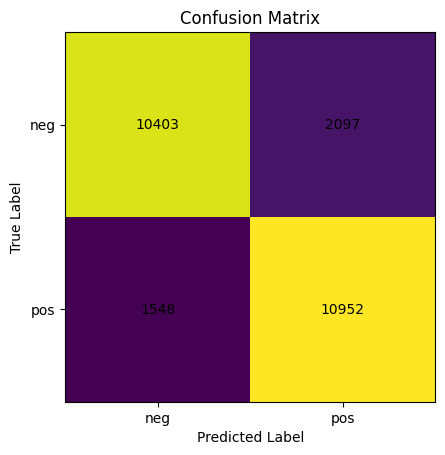

In [25]:
y_true = []
y_pred = []

for x_batch, y_batch in test_ds:
    probabilities = model.predict(x_batch, verbose=0).reshape(-1)
    predictions = (probabilities >= 0.5).astype("int32")

    y_true.extend(y_batch.numpy())
    y_pred.extend(predictions)

cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=2).numpy()

print("Confusion Matrix:")
print(cm)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["neg", "pos"])
plt.yticks([0, 1], ["neg", "pos"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

## 18. Membuat Model End-to-End untuk Prediksi Teks Mentah

Sampai saat ini, model utama menerima input berupa angka hasil `TextVectorization`.

Agar lebih praktis, kita buat model baru yang menerima teks mentah langsung.

Strukturnya:

```text
Teks mentah
    ↓
TextVectorization
    ↓
Model klasifikasi
    ↓
Probabilitas review positif
```

Ini berguna ketika model akan digunakan di aplikasi nyata.

In [26]:
export_model = tf.keras.Sequential([
    vectorize_layer,
    model
])

export_model.compile(
    loss=losses.BinaryCrossentropy(),
    optimizer="adam",
    metrics=["accuracy"]
)

metrics = export_model.evaluate(raw_test_ds, return_dict=True)
print(metrics)

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8542 - loss: 0.3630
{'accuracy': 0.854200005531311, 'loss': 0.3630332946777344}


## 19. Prediksi Review Baru

Sekarang kita coba masukkan kalimat review buatan sendiri.

Aturan interpretasi:

```text
probabilitas >= 0.5 → positif
probabilitas < 0.5  → negatif
```

In [27]:
def predict_review(text):
    probability = float(export_model.predict(tf.constant([text]), verbose=0)[0][0])
    label = "positif" if probability >= 0.5 else "negatif"

    print("Review:")
    print(text)
    print(f"Probabilitas positif: {probability:.4f}")
    print("Prediksi:", label)
    print("-" * 80)

examples = [
    "The movie was fantastic. I loved the story and the acting.",
    "The film was boring, too long, and not interesting at all.",
    "It was okay. Some parts were good, but some parts were disappointing.",
    "A wonderful movie with strong characters and beautiful music.",
    "I regret watching this movie. The plot was terrible."
]

for example in examples:
    predict_review(example)

Review:
The movie was fantastic. I loved the story and the acting.
Probabilitas positif: 0.6726
Prediksi: positif
--------------------------------------------------------------------------------
Review:
The film was boring, too long, and not interesting at all.
Probabilitas positif: 0.4420
Prediksi: negatif
--------------------------------------------------------------------------------
Review:
It was okay. Some parts were good, but some parts were disappointing.
Probabilitas positif: 0.5240
Prediksi: positif
--------------------------------------------------------------------------------
Review:
A wonderful movie with strong characters and beautiful music.
Probabilitas positif: 0.7487
Prediksi: positif
--------------------------------------------------------------------------------
Review:
I regret watching this movie. The plot was terrible.
Probabilitas positif: 0.4083
Prediksi: negatif
--------------------------------------------------------------------------------


## 20. Menyimpan Model

Model end-to-end dapat disimpan agar bisa digunakan kembali tanpa training ulang.

Format `.keras` adalah format penyimpanan model Keras modern.

> Catatan: Karena kita memakai fungsi preprocessing kustom, fungsi tersebut sudah didaftarkan menggunakan `@tf.keras.utils.register_keras_serializable`.

In [52]:
export_model.save("model_sentimen_imdb.keras")
print("Model berhasil disimpan sebagai model_sentimen_imdb.keras")

Model berhasil disimpan sebagai model_sentimen_imdb.keras


## 21. Memuat Kembali Model

Sel berikut bersifat opsional. Gunakan untuk memastikan model yang disimpan dapat dibuka kembali.

In [30]:
loaded_model = tf.keras.models.load_model("model_sentimen_imdb.keras")

predict_text = tf.constant(["This movie was amazing and very enjoyable."])
loaded_prediction = loaded_model.predict(predict_text, verbose=0)

print("Prediksi dari model yang dimuat ulang:", loaded_prediction[0][0])

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 8 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Prediksi dari model yang dimuat ulang: 0.7099958


## Latihan 1. Prediksi Kalimat Sendiri

Ubah isi variabel `my_review` dengan review buatan Anda sendiri. Jalankan prediksi dan jelaskan hasilnya.

Pertanyaan refleksi:

1. Apakah prediksi model sesuai ekspektasi Anda?
2. Apakah kalimat netral lebih sulit diprediksi dibanding kalimat sangat positif atau sangat negatif?

In [31]:
my_review = "This movie was not perfect, but I enjoyed many parts of it."

predict_review(my_review)

Review:
This movie was not perfect, but I enjoyed many parts of it.
Probabilitas positif: 0.6915
Prediksi: positif
--------------------------------------------------------------------------------


In [32]:
my_review = "This movie was fantastic. The acting was excellent, and the story was amazing."

predict_review(my_review)

Review:
This movie was fantastic. The acting was excellent, and the story was amazing.
Probabilitas positif: 0.7072
Prediksi: positif
--------------------------------------------------------------------------------


Pertanyaan refleksi:

1. Apakah prediksi model sesuai ekspektasi Anda?

   Jawaban : Ya, prediksi model sesuai ekspektasi saya karena kalimat banyak menggunakan kalimat positif seperti : fantastic,  excellent, dan amazing

2. Apakah kalimat netral lebih sulit diprediksi dibanding kalimat sangat positif atau sangat negatif?

   Jawaban : Ya, kalimat yang sangat positif atau sangat negatif lebih mudah diprediksi karena memiliki kata-kata yang jelas menunjukkan sentimen. Kalimat netral lebih sulit diprediksi karena model harus menentukan sentimen yang lebih dominan

## Latihan 2. Ubah `embedding_dim`

Pada model awal, kita menggunakan:

```python
embedding_dim = 16
```

Cobalah nilai lain:

```python
embedding_dim = 8
embedding_dim = 32
embedding_dim = 64
```

Catat:

1. Apakah training menjadi lebih lambat?
2. Apakah validation accuracy meningkat?
3. Apakah model mulai overfitting?

Jawaban :

In [33]:
embedding_dim = 8

model = tf.keras.Sequential([
    layers.Embedding(input_dim=max_features, output_dim=embedding_dim),
    layers.Dropout(0.2),
    layers.GlobalAveragePooling1D(),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

model.compile(
    loss=losses.BinaryCrossentropy(),
    optimizer="adam",
    metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy", threshold=0.5)]
)

epochs = 5

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6324 - loss: 0.6740 - val_accuracy: 0.7288 - val_loss: 0.6421
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7487 - loss: 0.5963 - val_accuracy: 0.7834 - val_loss: 0.5533
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8070 - loss: 0.5088 - val_accuracy: 0.8188 - val_loss: 0.4781
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8371 - loss: 0.4425 - val_accuracy: 0.8370 - val_loss: 0.4266
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8541 - loss: 0.3974 - val_accuracy: 0.8494 - val_loss: 0.3910


In [34]:
embedding_dim = 32

model = tf.keras.Sequential([
    layers.Embedding(input_dim=max_features, output_dim=embedding_dim),
    layers.Dropout(0.2),
    layers.GlobalAveragePooling1D(),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

model.compile(
    loss=losses.BinaryCrossentropy(),
    optimizer="adam",
    metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy", threshold=0.5)]
)

epochs = 5

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6657 - loss: 0.6435 - val_accuracy: 0.7534 - val_loss: 0.5689
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.8043 - loss: 0.4928 - val_accuracy: 0.8336 - val_loss: 0.4383
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8480 - loss: 0.3928 - val_accuracy: 0.8550 - val_loss: 0.3748
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8694 - loss: 0.3380 - val_accuracy: 0.8684 - val_loss: 0.3411
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.8817 - loss: 0.3013 - val_accuracy: 0.8732 - val_loss: 0.3203


In [35]:
embedding_dim = 64

model = tf.keras.Sequential([
    layers.Embedding(input_dim=max_features, output_dim=embedding_dim),
    layers.Dropout(0.2),
    layers.GlobalAveragePooling1D(),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

model.compile(
    loss=losses.BinaryCrossentropy(),
    optimizer="adam",
    metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy", threshold=0.5)]
)

epochs = 5

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.6834 - loss: 0.6216 - val_accuracy: 0.7964 - val_loss: 0.5188
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.8223 - loss: 0.4429 - val_accuracy: 0.8494 - val_loss: 0.3941
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.8597 - loss: 0.3518 - val_accuracy: 0.8622 - val_loss: 0.3455
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.8813 - loss: 0.3033 - val_accuracy: 0.8694 - val_loss: 0.3199
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.8943 - loss: 0.2716 - val_accuracy: 0.8750 - val_loss: 0.3056


1. Apakah training menjadi lebih lambat?

   Jawaban : Ya, karena semakin besar nilai embedding_dim, maka semakin banyak parameter yang harus dipelajari sehingga waktu pelatihan menjadi lebih lama

2. Apakah validation accuracy meningkat?

   Jawaban : Ya, validation accuracy meningkat saat embedding_dim di ubah 32 dan 64 karena model mempelajari representasi kata yang lebih baik

3. Apakah model mulai overfitting?

   Jawaban : Ya, model mulai overfitting yang ditandai dengan meningkatnya akurasi pada data tetapi tidak diikuti peningkatan akurasi pada data validasi

## Latihan 3. Ubah Panjang Sequence

Pada vectorization, kita menggunakan:

```python
sequence_length = 250
```

Cobalah nilai:

```python
sequence_length = 100
sequence_length = 500
```

Diskusikan:

1. Apa yang terjadi jika sequence terlalu pendek?
2. Apa konsekuensi jika sequence terlalu panjang?
3. Apakah akurasi berubah signifikan?

Jawaban :

```python
sequence_length = 100
```

In [36]:
max_features = 10000      # Maksimum jumlah kata dalam vocabulary
sequence_length = 100     # Panjang maksimum setiap review setelah vectorization

vectorize_layer = layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=max_features,
    output_mode="int",
    output_sequence_length=sequence_length
)

# Ambil hanya teks dari dataset training, tanpa label.
train_text = raw_train_ds.map(lambda text, label: text)

# adapt() membuat vocabulary berdasarkan data training.
# Jangan gunakan validation/test data untuk adapt, karena itu menyebabkan data leakage.
vectorize_layer.adapt(train_text)

print("Jumlah kata dalam vocabulary:", len(vectorize_layer.get_vocabulary()))
print("10 kata pertama dalam vocabulary:")
print(vectorize_layer.get_vocabulary()[:10])

Jumlah kata dalam vocabulary: 10000
10 kata pertama dalam vocabulary:
['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('a'), np.str_('of'), np.str_('to'), np.str_('is'), np.str_('in'), np.str_('it')]


In [37]:
for text_batch, label_batch in raw_train_ds.take(1):
    first_review = text_batch[0]
    first_label = label_batch[0]

    print("Review asli:")
    print(first_review.numpy()[:500])

    print("\nLabel:", raw_train_ds.class_names[first_label.numpy()])

    vectorized_review = vectorize_layer(tf.expand_dims(first_review, -1))

    print("\n20 token pertama setelah vectorization:")
    print(vectorized_review.numpy()[0][:20])
    break

Review asli:
b'Every scene was put together perfectly.This movie had a wonderful cast and crew. I mean, how can you have a bad movie with Robert Downey Jr. in it,none have and ever will exist. He has the ability to brighten up any movie with his amazing talent.This movie was perfect! I saw this movie sitting all alone on a movie shelf in "Blockbuster" and like it was calling out to me,I couldn\'t resist picking it up and bringing it home with me. You can call me a sappy romantic, but this movie just touched my '

Label: pos

20 token pertama setelah vectorization:
[ 165  134   13  268  281    1   17   66    4  386  173    3 1037   10
  380   87   68   22   25    4]


In [38]:
vocab = vectorize_layer.get_vocabulary()

print("Contoh mapping indeks ke kata:")
for index in [1, 2, 3, 10, 100, 1000]:
    if index < len(vocab):
        print(f"{index} -> {vocab[index]}")

Contoh mapping indeks ke kata:
1 -> [UNK]
2 -> the
3 -> and
10 -> i
100 -> characters
1000 -> political


In [39]:
def vectorize_text(text, label):
    text = tf.expand_dims(text, -1)
    return vectorize_layer(text), label

train_ds = raw_train_ds.map(vectorize_text)
val_ds = raw_val_ds.map(vectorize_text)
test_ds = raw_test_ds.map(vectorize_text)

for x_batch, y_batch in train_ds.take(1):
    print("Shape input batch:", x_batch.shape)
    print("Shape label batch:", y_batch.shape)
    print("Contoh input pertama, 20 angka pertama:")
    print(x_batch.numpy()[0][:20])

Shape input batch: (32, 100)
Shape label batch: (32,)
Contoh input pertama, 20 angka pertama:
[   2  314    1    4   52  350   19   16    4  171    5 1574  217  424
    3  874    2  508 1733   50]


```python
sequence_length = 500
```

In [40]:
max_features = 10000      # Maksimum jumlah kata dalam vocabulary
sequence_length = 500     # Panjang maksimum setiap review setelah vectorization

vectorize_layer = layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=max_features,
    output_mode="int",
    output_sequence_length=sequence_length
)

# Ambil hanya teks dari dataset training, tanpa label.
train_text = raw_train_ds.map(lambda text, label: text)

# adapt() membuat vocabulary berdasarkan data training.
# Jangan gunakan validation/test data untuk adapt, karena itu menyebabkan data leakage.
vectorize_layer.adapt(train_text)

print("Jumlah kata dalam vocabulary:", len(vectorize_layer.get_vocabulary()))
print("10 kata pertama dalam vocabulary:")
print(vectorize_layer.get_vocabulary()[:10])

Jumlah kata dalam vocabulary: 10000
10 kata pertama dalam vocabulary:
['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('a'), np.str_('of'), np.str_('to'), np.str_('is'), np.str_('in'), np.str_('it')]


In [41]:
for text_batch, label_batch in raw_train_ds.take(1):
    first_review = text_batch[0]
    first_label = label_batch[0]

    print("Review asli:")
    print(first_review.numpy()[:500])

    print("\nLabel:", raw_train_ds.class_names[first_label.numpy()])

    vectorized_review = vectorize_layer(tf.expand_dims(first_review, -1))

    print("\n20 token pertama setelah vectorization:")
    print(vectorized_review.numpy()[0][:20])
    break

Review asli:
b'If you want Scream or anything like the big-studio horror product that we get forced on us these days don\'t bother. This well-written film kept me up thinking about all it had to say. Importance of myth in our lives to make it make sense, how children interpret the world (and the violence in it), our ransacking of the environment and ignorance of its history and legends.. all here, but not flatly on the surface. You could technically call it a "monster movie" even though the Wendigo does not tak'

Label: pos

20 token pertama setelah vectorization:
[  45   22  178 2004   41  228   38    2    1  191 2218   12   71   75
  892   20  167  129  476   89]


In [43]:
vocab = vectorize_layer.get_vocabulary()

print("Contoh mapping indeks ke kata:")
for index in [1, 2, 3, 10, 100, 1000]:
    if index < len(vocab):
        print(f"{index} -> {vocab[index]}")

Contoh mapping indeks ke kata:
1 -> [UNK]
2 -> the
3 -> and
10 -> i
100 -> characters
1000 -> political


In [44]:
def vectorize_text(text, label):
    text = tf.expand_dims(text, -1)
    return vectorize_layer(text), label

train_ds = raw_train_ds.map(vectorize_text)
val_ds = raw_val_ds.map(vectorize_text)
test_ds = raw_test_ds.map(vectorize_text)

for x_batch, y_batch in train_ds.take(1):
    print("Shape input batch:", x_batch.shape)
    print("Shape label batch:", y_batch.shape)
    print("Contoh input pertama, 20 angka pertama:")
    print(x_batch.numpy()[0][:20])

Shape input batch: (32, 500)
Shape label batch: (32,)
Contoh input pertama, 20 angka pertama:
[   1    7    4  191   17 2926   12  255  127   50  377   70  160  256
   69   51   10  361   22   10]


1. Apa yang terjadi jika sequence terlalu pendek?

   Jawaban : jika sequence terlalu pendek sequence_length = 100,  maka review hanya akan diproses hingga 100 kata pertama dan informasi penting yang berada di bagian akhir review dapat hilang sehingga model tidak memperoleh data yang lengkap untuk melakukan klasifikasi sentimen

2. Apa konsekuensi jika sequence terlalu panjang?
   
   Jawaban : jika sequence terlalu panjang sequence_length = 500, maka model dapat memproses lebih banyak kata dari setiap review dan informasi yang diterima lebih lengkap. Kekurangannya adalah proses training menjadi lebih lambat dan penggunaan RAM/GPU meningkat

3. Apakah akurasi berubah signifikan?
   
   Jawaban : akurasi belum berubah secara signifikan, karena sequence_length = 100 akurasi dapat sedikit menurun apabila banyak informasi berada setelah kata ke-100 dan sequence_length = 500 belum tentu meningkatkan akurasi saat memproses lebih banyak kata

## Latihan 4. Gunakan EarlyStopping

Tambahkan callback berikut saat `model.fit()`:

```python
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)
```

Lalu panggil:

```python
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping]
)
```

Tugas:

1. Amati pada epoch ke berapa training berhenti.
2. Jelaskan mengapa EarlyStopping dapat membantu mengurangi overfitting.

Jawaban :

In [45]:
model.compile(
    loss=losses.BinaryCrossentropy(),
    optimizer="adam",
    metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy", threshold=0.5)]
)

In [46]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [47]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 45ms/step - accuracy: 0.8805 - loss: 0.3211 - val_accuracy: 0.8812 - val_loss: 0.3256
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 35ms/step - accuracy: 0.8914 - loss: 0.2873 - val_accuracy: 0.8826 - val_loss: 0.3089
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.9021 - loss: 0.2626 - val_accuracy: 0.7900 - val_loss: 0.4217
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 36ms/step - accuracy: 0.8982 - loss: 0.2562 - val_accuracy: 0.8780 - val_loss: 0.2980
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.9052 - loss: 0.2425 - val_accuracy: 0.8888 - val_loss: 0.2850
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.9108 - loss: 0.2317 - val_accuracy: 0.8736 - val_loss: 0.3042
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.9193 - loss: 0.2153 - val_accuracy: 0.8908 - val_loss: 0.2759
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.9227 - loss: 0.2074 - 

1. Amati pada epoch ke berapa training berhenti.

   Jawaban : training berhenti pada epoch ke 11

2. Jelaskan mengapa EarlyStopping dapat membantu mengurangi overfitting.
   
   Jawaban : EarlyStopping dapat membantu mengurangi overfitting karena  proses training dihentikan secara otomatis pada data validasi tidak lagi meningkat dan membantu menghasilkan model yang lebih baik dalam memprediksi data baru

## Latihan 5. Ubah Threshold Klasifikasi

Saat ini threshold yang digunakan adalah:

```text
0.5
```

Artinya:
- probabilitas positif ≥ 0.5 → positif
- probabilitas positif < 0.5 → negatif

Cobalah threshold:

```python
0.4
0.6
0.7
```

Pertanyaan:

1. Apakah jumlah prediksi positif berubah?
2. Bagaimana dampaknya terhadap confusion matrix?
3. Dalam aplikasi nyata, kapan kita perlu menaikkan atau menurunkan threshold?

Jawaban :

In [49]:
# Contoh eksperimen threshold

threshold = 0.4

y_true_threshold = []
y_pred_threshold = []

for x_batch, y_batch in test_ds:
    probabilities = model.predict(x_batch, verbose=0).reshape(-1)
    predictions = (probabilities >= threshold).astype("int32")

    y_true_threshold.extend(y_batch.numpy())
    y_pred_threshold.extend(predictions)

cm_threshold = tf.math.confusion_matrix(
    y_true_threshold,
    y_pred_threshold,
    num_classes=2
).numpy()

print(f"Confusion Matrix dengan threshold = {threshold}")
print(cm_threshold)

Confusion Matrix dengan threshold = 0.4
[[10397  2103]
 [  941 11559]]


In [50]:
# Contoh eksperimen threshold

threshold = 0.6

y_true_threshold = []
y_pred_threshold = []

for x_batch, y_batch in test_ds:
    probabilities = model.predict(x_batch, verbose=0).reshape(-1)
    predictions = (probabilities >= threshold).astype("int32")

    y_true_threshold.extend(y_batch.numpy())
    y_pred_threshold.extend(predictions)

cm_threshold = tf.math.confusion_matrix(
    y_true_threshold,
    y_pred_threshold,
    num_classes=2
).numpy()

print(f"Confusion Matrix dengan threshold = {threshold}")
print(cm_threshold)

Confusion Matrix dengan threshold = 0.6
[[11353  1147]
 [ 1756 10744]]


In [51]:
# Contoh eksperimen threshold

threshold = 0.7

y_true_threshold = []
y_pred_threshold = []

for x_batch, y_batch in test_ds:
    probabilities = model.predict(x_batch, verbose=0).reshape(-1)
    predictions = (probabilities >= threshold).astype("int32")

    y_true_threshold.extend(y_batch.numpy())
    y_pred_threshold.extend(predictions)

cm_threshold = tf.math.confusion_matrix(
    y_true_threshold,
    y_pred_threshold,
    num_classes=2
).numpy()

print(f"Confusion Matrix dengan threshold = {threshold}")
print(cm_threshold)

Confusion Matrix dengan threshold = 0.7
[[11679   821]
 [ 2439 10061]]


1. Apakah jumlah prediksi positif berubah?

   Jawaban : Ya, jumlah prediksi positif berubah ketika nilai threshold diubah

```text
0.4
```

Artinya :
  - probabilitas positif ≥ 0.4 → positif
  - probabilitas positif < 0.4 → negatif
  - batas klasifikasi lebih rendah, model lebih mudah mengklasifikasikan data sebagai positif, sehingga jumlah prediksi positif meningkat

```text
0.6
```

Artinya :
  - probabilitas positif ≥ 0.6 → positif
  - probabilitas positif < 0.6 → negatif
  - jumlah prediksi positif menjadi lebih sedikit dibandingkan threshold 0.4

```text
0.7
```

Artinya:
  - probabilitas positif ≥ 0.7 → positif
  - probabilitas positif < 0.7 → negatif
  - jumlah prediksi positif menjadi paling sedikit dibandingkan threshold 0.4 dan 0.6

2. Bagaimana dampaknya terhadap confusion matrix?

   Jawaban : nilai threshold akan memengaruhi isi confusion matrix karena semakin rendah nilai threshold, banyak data yang diprediksi positif sehingga nilai pada confusion matrix ikut berubah. Jika semakin tinggi threshold maka komposisi True Positive, False Positive, True Negative, dan False Negative ikut berubah


3. Dalam aplikasi nyata, kapan kita perlu menaikkan atau menurunkan threshold?

   Jawaban : Dalam aplikasi nyata adalah mendeteksi email spam

  - Threshold diturunkan jika ingin mendeteksi lebih banyak email spam
  - Threshold dinaikkan jika tidak ingin email penting salah dimasukan ke folder spam

# Ringkasan

Pada notebook ini, kita telah mempelajari pipeline dasar klasifikasi teks menggunakan TensorFlow/Keras:

```text
Download dataset
    ↓
Baca file teks dari folder
    ↓
Bagi data menjadi train/validation/test
    ↓
Bersihkan teks
    ↓
Ubah teks menjadi angka dengan TextVectorization
    ↓
Bangun model Embedding sederhana
    ↓
Training model
    ↓
Evaluasi model
    ↓
Prediksi teks baru
```

Konsep paling penting:

1. **Teks harus diubah menjadi angka** sebelum masuk ke model.
2. **TextVectorization** membuat vocabulary dan mengubah kata menjadi indeks.
3. **Embedding** mengubah indeks kata menjadi vektor yang dipelajari selama training.
4. **Validation set** membantu memantau generalisasi model.
5. **Overfitting** terjadi ketika model terlalu hafal data training tetapi kurang baik pada data baru.
6. **Model end-to-end** memudahkan prediksi karena bisa menerima teks mentah secara langsung.

# Referensi

- TensorFlow — Basic text classification: https://www.tensorflow.org/tutorials/keras/text_classification
- TensorFlow API — `text_dataset_from_directory`: https://www.tensorflow.org/api_docs/python/tf/keras/utils/text_dataset_from_directory
- TensorFlow API — `TextVectorization`: https://www.tensorflow.org/api_docs/python/tf/keras/layers/TextVectorization
- TensorFlow API — `Embedding`: https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding